In [17]:
import pandas as pd
import numpy as np

from scipy.stats import (
    ttest_ind,
    f_oneway,
    chi2_contingency
)

In [4]:
df = pd.read_csv("../data/cleaned_data.csv")

/var/folders/td/g0nj9lw14y165dmqgtz9jxzh0000gn/T/ipykernel_7504/2527705676.py:1: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/cleaned_data.csv")


Feature Engineering

In [5]:
df["LossRatio"] = np.where(
    df["TotalPremium"] > 0,
    df["TotalClaims"] / df["TotalPremium"],
    np.nan
)

df["Margin"] = (
    df["TotalPremium"] - df["TotalClaims"]
)

df["LossRatio"] = df["LossRatio"].replace(
    [np.inf, -np.inf],
    np.nan
)

Province Risk Difference

In [6]:
province_groups = [
    group["LossRatio"].dropna()
    for _, group in df.groupby("Province")
]

anova_result = f_oneway(*province_groups)

print("Province Risk Difference")
print("F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)

Province Risk Difference
F-statistic: 4.96918412883474
p-value: 3.562505015220851e-06


Interpretation:

The ANOVA test produced a p-value below 0.05, indicating statistically significant differences in Loss Ratio across provinces.

This suggests that geographic location is an important driver of insurance risk and should be considered in underwriting and pricing decisions.

Gender Claim Difference

In [9]:
male_claims = df[
    df["Gender"] == "Male"
]["TotalClaims"]

female_claims = df[
    df["Gender"] == "Female"
]["TotalClaims"]

gender_test = ttest_ind(
    male_claims,
    female_claims,
    nan_policy="omit"
)

print("Gender Claim Difference")
print("t-statistic:", gender_test.statistic)
print("p-value:", gender_test.pvalue)

Gender Claim Difference
t-statistic: -0.24803623812388725
p-value: 0.8041073961270342


Interpretation:

The independent t-test produced a p-value greater than 0.05, indicating no statistically significant difference in TotalClaims between male and female policyholders.

This suggests gender alone may not be a strong predictor of claim behavior in this dataset.

Postal Code Risk Difference

In [10]:
postal_groups = [
    group["LossRatio"].dropna()
    for _, group in df.groupby("PostalCode")
]

postal_anova = f_oneway(*postal_groups[:20])

print("Postal Code Risk Difference")
print("F-statistic:", postal_anova.statistic)
print("p-value:", postal_anova.pvalue)

Postal Code Risk Difference
F-statistic: 0.9954750736605757
p-value: 0.46250326407216846


Interpretation:

The ANOVA test did not find statistically significant differences in Loss Ratio across sampled postal codes.

This indicates that postal code segmentation may provide less predictive value than broader geographic segmentation such as Province.

In [11]:
vehicle_groups = [
    group["Margin"].dropna()
    for _, group in df.groupby("VehicleType")
]

vehicle_test = f_oneway(*vehicle_groups)

print("Vehicle Margin Difference")
print("F-statistic:", vehicle_test.statistic)
print("p-value:", vehicle_test.pvalue)

Vehicle Margin Difference
F-statistic: 1.1343963860666528
p-value: 0.33811471779480706


Interpretation:

The ANOVA test showed no statistically significant difference in Margin across vehicle types.

Although some vehicle categories may exhibit different claim patterns, the differences were not statistically strong enough in this analysis.

Final Summary Table

In [12]:
summary = pd.DataFrame({
    "Hypothesis": [
        "Province Risk Difference",
        "Gender Claim Difference",
        "Postal Code Risk Difference",
        "Vehicle Margin Difference"
    ],
    "Test": [
        "ANOVA",
        "Independent t-test",
        "ANOVA",
        "ANOVA"
    ],
    "p-value": [
        anova_result.pvalue,
        gender_test.pvalue,
        postal_anova.pvalue,
        vehicle_test.pvalue
    ]
})

summary["Reject Null?"] = (
    summary["p-value"] < 0.05
)

summary

,Hypothesis,Test,p-value,Reject Null?
0,Province Risk Difference,ANOVA,0.000004,True
1,Gender Claim Difference,Independent t-test,0.804107,False
2,Postal Code Risk Difference,ANOVA,0.462503,False
3,Vehicle Margin Difference,ANOVA,0.338115,False


Overall Conclusion:

The hypothesis testing results indicate that Province is the strongest statistically significant segmentation variable among the tested groups.

Geographic factors appear to influence insurance risk more strongly than gender or vehicle type within this dataset. These findings support the use of geographic risk segmentation in pricing and underwriting strategies for ACIS Insurance.

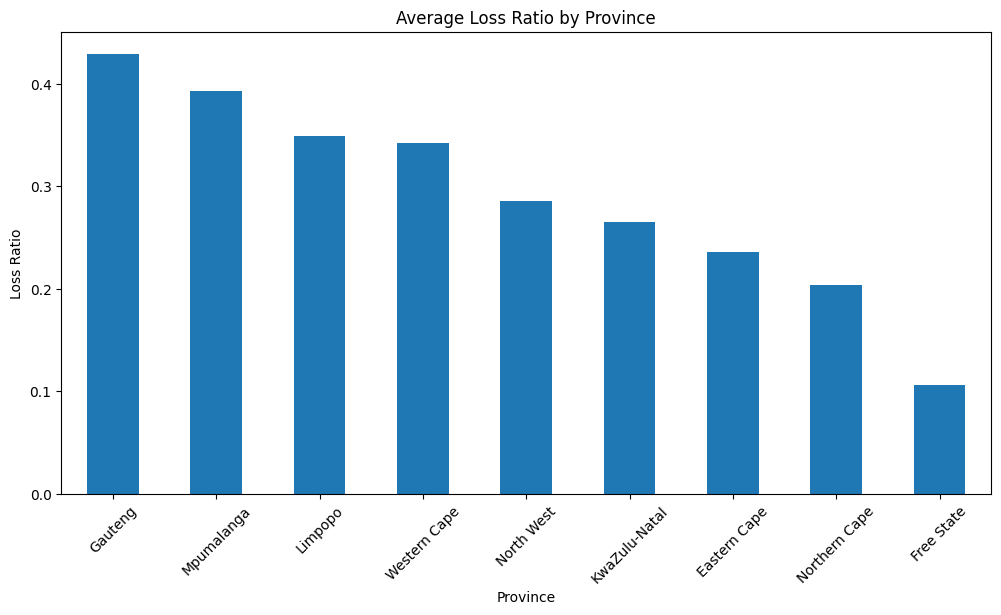

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
province_risk = df.groupby("Province")[
    "LossRatio"
].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))

province_risk.plot(kind="bar")

plt.title("Average Loss Ratio by Province")

plt.ylabel("Loss Ratio")

plt.xticks(rotation=45)

plt.show()

Gender vs Claim Presence

In [23]:
from scipy.stats import chi2_contingency

df["HasClaim"] = (df["TotalClaims"] > 0).astype(int)

contingency_table = pd.crosstab(df["Gender"], df["HasClaim"])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square Test")
print("p-value:", p)

Chi-square Test
p-value: 0.026570248768437138


In [25]:
from scipy.stats import chi2_contingency
import pandas as pd

df["HasClaim"] = (df["TotalClaims"] > 0).astype(int)

contingency_table = pd.crosstab(df["Gender"], df["HasClaim"])

chi2, chi_p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square p-value:", chi_p_value)

Chi-square p-value: 0.026570248768437138


In [26]:
summary = pd.DataFrame({
    "Hypothesis": [
        "Province Risk Difference",
        "Gender Claim Difference",
        "Postal Code Risk Difference",
        "Vehicle Margin Difference",
        "Gender vs Claim Presence"
    ],
    "Test": [
        "ANOVA",
        "t-test",
        "ANOVA",
        "ANOVA",
        "Chi-square"
    ],
    "p-value": [
        anova_result.pvalue,
        gender_test.pvalue,
        postal_anova.pvalue,
        vehicle_test.pvalue,
        chi_p_value
    ]
})

summary["Reject Null?"] = summary["p-value"] < 0.05

summary

,Hypothesis,Test,p-value,Reject Null?
0,Province Risk Difference,ANOVA,0.000004,True
1,Gender Claim Difference,t-test,0.804107,False
2,Postal Code Risk Difference,ANOVA,0.462503,False
3,Vehicle Margin Difference,ANOVA,0.338115,False
4,Gender vs Claim Presence,Chi-square,0.026570,True
